# Proyek Analisis Data: E-Commere Public

- Nama: Nicolas Debrito
- Email: nicolas.debrito66@gmail.com
- Id Dicoding: reezzy

## Menentukan Pertanyaan Bisnis

- Bagaimana performa respon penjual berdasarkan waktu pesanan dan waktu diterima?
- Apa produk dengan nilai review tertinggi dan terendah?
- Bagaimana persebaran tempat tinggal pembeli dan penjual?

## Menyiapkan semua library yang dibuthkan

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

## Data Wrangling

### Gathering Data

In [3]:
customers_df = pd.read_csv('data/customers_dataset.csv')
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


Mengakses customers_dataset.csv menjadi dataframe 

In [4]:
geolocation_df = pd.read_csv('data/geolocation_dataset.csv')
geolocation_df.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


Mengakses geolocation_dataset.csv menjadi dataframe

In [5]:
order_items_df = pd.read_csv('data/order_items_dataset.csv')
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


Mengakses order_items_dataset.csv menjadi dataframe

In [6]:
order_payments_df = pd.read_csv('data/order_payments_dataset.csv')
order_payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


Mengakses order_payments_datase.csv menjadi dataframe

In [7]:
order_reviews_df = pd.read_csv('data/order_reviews_dataset.csv')
order_reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


Mengakses order_reviews_dataset menjadi dataframe

In [8]:
orders_df = pd.read_csv('data/orders_dataset.csv')
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


Mengakses orders_dataset.csv menjadi dataframe

In [9]:
product_category_name_df = pd.read_csv('data/product_category_name_translation.csv')
product_category_name_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


Mengakses product_category_name_translation.csv menjadi dataframe

In [10]:
products_df = pd.read_csv('data/products_dataset.csv')
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


Mengakses products_dataset.csv menjadi dataframe

In [11]:
sellers_df = pd.read_csv('data/sellers_dataset.csv')
sellers_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


Mengakses sellers_dataset.csv menjadi dataframe

### Assessing Data

In [12]:
customers_df.info()
print("jumlah duplikasi: ", customers_df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
jumlah duplikasi:  0


Setelah dilakukan pengecekan menggunakan .info() dan .duplicated() diketahui tidak ada missing value ataupun duplikasi yang perlu dibersihkan.

In [13]:
customers_df.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


Tidak ada keanehan pada deskripsi customers_df 

In [14]:
geolocation_df.info()
print("jumlah duplikasi: ", geolocation_df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


jumlah duplikasi:  261831


Setelah dilakukan pengecekan menggunakan .info() dan .duplicated() diketahui tidak ada missing value tapi terdapat duplikasi yang perlu dibersihkan. 

In [15]:
geolocation_df.describe()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
count,1.000163e+06,1.000163e+06,1.000163e+06
mean,3.657417e+04,-2.117615e+01,-4.639054e+01
std,3.054934e+04,5.715866e+00,4.269748e+00
min,1.001000e+03,-3.660537e+01,-1.014668e+02
25%,1.107500e+04,-2.360355e+01,-4.857317e+01
50%,2.653000e+04,-2.291938e+01,-4.663788e+01
75%,6.350400e+04,-1.997962e+01,-4.376771e+01
max,9.999000e+04,4.506593e+01,1.211054e+02


Tidak ada keanehan pada deskripsi geolocation_df

In [16]:
geolocation_df.sort_values(by="geolocation_zip_code_prefix")

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
1246,1001,-23.549292,-46.633559,sao paulo,SP
429,1001,-23.550498,-46.634338,sao paulo,SP
1182,1001,-23.549779,-46.633957,sao paulo,SP
1435,1001,-23.549292,-46.633559,sao paulo,SP
326,1001,-23.551427,-46.634074,sao paulo,SP
...,...,...,...,...,...
1000026,99980,-28.388679,-51.848863,david canabarro,RS
999950,99980,-28.388400,-51.845225,david canabarro,RS
1000002,99980,-28.388342,-51.845194,david canabarro,RS
999864,99990,-28.329472,-51.769109,muliterno,RS


Terlihat geolocation_zip_code_prefix tidak bersifat unique. 

In [17]:
order_items_df.info()
print("jumlah duplikasi: ", order_items_df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB
jumlah duplikasi:  0


Setelah dilakukan pengecekan menggunakan .info() dan .duplicated() diketahui tidak ada missing value ataupun duplikasi yang perlu dibersihkan. 

In [18]:
order_items_df.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


Tidak terdapat keanehan pada deskripsi order_items_df

In [19]:
order_payments_df.info()
print("jumlah duplikasi: ", order_payments_df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB
jumlah duplikasi:  0


Setelah dilakukan pengecekan menggunakan .info() dan .duplicated() diketahui tidak ada missing value ataupun duplikasi yang perlu dibersihkan. 

In [20]:
order_payments_df.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


Tidak ada keanehan pada deskripsi order_payments_df

In [21]:
order_reviews_df.info()
print("jumlah duplikasi: ", order_reviews_df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB
jumlah duplikasi:  0


Setelah dilakukan pengecekan menggunakan .info() dan .duplicated() diketahui tidak ada duplikasi, tapi terdapat missing value pada review_comment_title dan review_comment_message serta ada kesalahan pada tipedata di review_creation_date dan review_answer_timestamp.

In [22]:
order_reviews_df.describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


Tidak ada keanehan pada deskripsi order_review_df

In [23]:
orders_df.info()
print("jumlah duplikasi: ", orders_df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
jumlah duplikasi:  0


Setelah dilakukan pengecekan menggunakan .info() dan .duplicated() diketahui tidak ada duplikasi, tapi terdapat missing value pada order_approved_at, order_delivered_carrier_date, order_delivered_customer_date selain itu terdapat kesalahan tipe data pada order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date.

In [24]:
orders_df.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-04-11 10:48:14,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 23:38:46,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


Tidak ada keanehan pada deskripsi orders_df

In [25]:
product_category_name_df.info()
print("jumlah duplikasi: ", product_category_name_df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB
jumlah duplikasi:  0


Setelah dilakukan pengecekan menggunakan .info() dan .duplicated() diketahui tidak ada missing value ataupun duplikasi yang perlu dibersihkan. 

In [26]:
product_category_name_df.describe()

,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


Tidak ada keanehan pada deskripsi product_category_name_df

In [27]:
products_df.info()
print("jumlah duplikasi: ", products_df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB
jumlah duplikasi:  0


Setelah dilakukan pengecekan menggunakan .info() dan .duplicated() diketahui tidak ada duplikasi, tapi terdapat missing value pada product_category_name, product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm.

In [28]:
products_df.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


Tidak ada keanehan pada products_df

In [29]:
sellers_df.info()
print("jumlah duplikasi: ", sellers_df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB
jumlah duplikasi:  0


Setelah dilakukan pengecekan menggunakan .info() dan .duplicated() diketahui tidak ada missing value ataupun duplikasi yang perlu dibersihkan. 

In [30]:
sellers_df.describe()

,seller_zip_code_prefix
count,3095.000000
mean,32291.059451
std,32713.453830
min,1001.000000
25%,7093.500000
50%,14940.000000
75%,64552.500000
max,99730.000000


Tidak ada keanehan pada sellers_df

### Cleaning Data

Melakukan penghapusan duplikasi data dan membuat geolocation_zip_code_prefix menjadi unique dengan menggunakan mean geolocation_lat dan geolocation_lng pada geolocation_df.

In [31]:
geolocation_df.drop_duplicates(inplace=True)
print("jumlah duplikasi: ", geolocation_df.duplicated().sum())
geolocation_df

jumlah duplikasi:  0


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP
...,...,...,...,...,...
1000155,99965,-28.180655,-52.034367,agua santa,RS
1000156,99950,-28.072188,-52.011272,tapejara,RS
1000157,99950,-28.068864,-52.012964,tapejara,RS
1000158,99950,-28.068639,-52.010705,tapejara,RS


In [32]:
geolocation_unique_df = geolocation_df.groupby('geolocation_zip_code_prefix').agg({
    "geolocation_lat": "mean",
    "geolocation_lng": "mean"})
geolocation_unique_df

,geolocation_lat,geolocation_lng
geolocation_zip_code_prefix,,
1001,-23.550227,-46.634039
1002,-23.547657,-46.634991
1003,-23.549000,-46.635582
1004,-23.549829,-46.634792
1005,-23.549547,-46.636406
...,...,...
99960,-27.953722,-52.025511
99965,-28.183372,-52.039850
99970,-28.343920,-51.874988


Mengisi missing value pada review_comment_title dan review_comment_message yang kosong dengan "Tidak ada" dan mengubah tipedata di review_creation_date dan review_answer_timestamp menjadi datetime pada order_reviews_df.

In [33]:
order_reviews_df["review_comment_title"].replace({None : "Tidak ada"}, inplace=True)
order_reviews_df["review_comment_message"].replace({None : "Tidak ada"}, inplace=True)
order_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     99224 non-null  object
 4   review_comment_message   99224 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [34]:
order_reviews_df["review_creation_date"] = pd.to_datetime(order_reviews_df["review_creation_date"])
order_reviews_df["review_answer_timestamp"] = pd.to_datetime(order_reviews_df["review_answer_timestamp"])
order_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  int64         
 3   review_comment_title     99224 non-null  object        
 4   review_comment_message   99224 non-null  object        
 5   review_creation_date     99224 non-null  datetime64[ns]
 6   review_answer_timestamp  99224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 5.3+ MB


 Mengubah tipe data pada order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date menjadi datetime dan menghapus missing value pada order_approved_at, order_delivered_carrier_date, order_delivered_customer_date pada orders_df. Penghapusan dilakukan karena sulit untuk menentukan tanggal yang sesuai antara order_approved_at dengan order_delivered_customer_date berdasarkan data sebelum dan sesudah, juga data yang mengalami missing value hanya sedikit.

In [35]:
columns = ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date", "order_estimated_delivery_date"]
for column in columns:
    orders_df[column] = pd.to_datetime(orders_df[column])
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [36]:
orders_df.dropna(axis=0, inplace=True)
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96461 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96461 non-null  object        
 1   customer_id                    96461 non-null  object        
 2   order_status                   96461 non-null  object        
 3   order_purchase_timestamp       96461 non-null  datetime64[ns]
 4   order_approved_at              96461 non-null  datetime64[ns]
 5   order_delivered_carrier_date   96461 non-null  datetime64[ns]
 6   order_delivered_customer_date  96461 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96461 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.6+ MB


Menghapus missing value pada product_category_name, product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm. Penghapusan dilakukan karena tidak ada rujukan untuk menentukan missing value dan jumlah baris yang terdapat missing value hanya sedikit.

In [37]:
products_df.dropna(axis=0, inplace=True)
products_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32340 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32340 non-null  object 
 1   product_category_name       32340 non-null  object 
 2   product_name_lenght         32340 non-null  float64
 3   product_description_lenght  32340 non-null  float64
 4   product_photos_qty          32340 non-null  float64
 5   product_weight_g            32340 non-null  float64
 6   product_length_cm           32340 non-null  float64
 7   product_height_cm           32340 non-null  float64
 8   product_width_cm            32340 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.5+ MB


## Exploratory Data Analysis (EDA)

## Explore ...

Melakukan eksplorasi customers_df dan geolocation_df dengan menggabungkan customer dengan lokasi daerah tempat tinggalnya pada peta.

In [38]:
customers__geolocation_df = pd.merge(
    customers_df, geolocation_unique_df,
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='inner')
customers__geolocation_df["role"] = "customer"
customers__geolocation_df

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,geolocation_lat,geolocation_lng,role
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,-20.499273,-47.396658,customer
1,5dca924cc99eea2dc5ba40d11ec5dd0f,2761fee7f378f0a8d7682d8a3fa07ab1,14409,franca,SP,-20.499273,-47.396658,customer
2,661897d4968f1b59bfff74c7eb2eb4fc,d06a495406b79cb8203ea21cc0942f8c,14409,franca,SP,-20.499273,-47.396658,customer
3,702b62324327ccba20f1be3465426437,8b3d988f330c1d1c3332ccd440c147b7,14409,franca,SP,-20.499273,-47.396658,customer
4,bdf997bae7ca819b0415f5174d6b4302,866755e25db620f8d7e81b351a15bb2f,14409,franca,SP,-20.499273,-47.396658,customer
...,...,...,...,...,...,...,...,...
99158,0b7a30ba373aeb55cf28add5b5477956,8c8173e547e020f411aa55b2fceed861,87145,paicandu,PR,-23.501806,-52.150926,customer
99159,ff6b440b2465bfaef05c675efb48cd15,e38a27b979a552e019e297ecc22dc67b,98860,eugenio de castro,RS,-28.527713,-54.146075,customer
99160,3f7029d9b98a47370cd5f3a97adcbccd,5894d202cc869b4ec460fce3c6ed8cb5,5538,sao paulo,SP,-23.588483,-46.737908,customer
99161,d9110683c7a282144e9fc97660026a28,5cbfdb85ec130898108b32c50d619c39,74980,aparecida de goiania,GO,-16.822834,-49.250203,customer


In [39]:
customers__geolocation_df.groupby(by="customer_city").customer_id.nunique().sort_values(ascending=False)

customer_city
sao paulo                  15538
rio de janeiro              6882
belo horizonte              2773
brasilia                    1960
curitiba                    1521
                           ...  
santa barbara do para          1
centralina                     1
centro novo do maranhao        1
cerejeiras                     1
sao felix do coribe            1
Name: customer_id, Length: 4074, dtype: int64

Diketahui jumlah pembeli terpusat pada sao paulo dengan total 15538 orang.

Melakukan eksplorasi sellers_df dan geolocation_df dengan menggabungkan seller dengan lokasi daerah tempat tinggalnya pada peta.

In [40]:
sellers_geolocation_df = pd.merge(
    sellers_df, geolocation_unique_df,
    left_on='seller_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='inner')
sellers_geolocation_df["role"] = "seller"
sellers_geolocation_df

,seller_id,seller_zip_code_prefix,seller_city,seller_state,geolocation_lat,geolocation_lng,role
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,-22.893317,-47.060596,seller
1,e0eabded302882513ced4ea3eb0c7059,13023,campinas,SP,-22.893317,-47.060596,seller
2,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP,-22.383375,-46.948142,seller
3,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ,-22.909446,-43.180240,seller
4,1d2732ef8321502ee8488e8bed1ab8cd,20031,rio de janeiro,RJ,-22.909446,-43.180240,seller
...,...,...,...,...,...,...,...
3083,f1fdf2d13186575751aa25876536d85c,5314,sao paulo,SP,-23.531010,-46.736147,seller
3084,98dddbc4601dd4443ca174359b237166,87111,sarandi,PR,-23.447681,-51.870101,seller
3085,74871d19219c7d518d0090283e03c137,4650,sao paulo,SP,-23.657564,-46.676434,seller
3086,e603cf3fec55f8697c9059638d6c8eb5,96080,pelotas,RS,-31.750845,-52.322765,seller


In [41]:
sellers_geolocation_df.groupby("seller_city").seller_id.nunique().sort_values(ascending=False)

seller_city
sao paulo         693
curitiba          126
rio de janeiro     96
belo horizonte     68
ribeirao preto     52
                 ... 
ivoti               1
itirapina           1
itau de minas       1
itapui              1
xaxim               1
Name: seller_id, Length: 611, dtype: int64

Diketahui jumlah penjual terpusat pada sao paulo sebanyak 693 orang.

Melakukan eksplorasi orders_df dengan menambahkan atribut response_time_hour untuk mengetahui waktu yang dibutuhkan penjual untuk merespon pembelian.

In [42]:
response_time = orders_df["order_approved_at"] - orders_df["order_purchase_timestamp"]
response_time = response_time.apply(lambda x: x.total_seconds())
orders_df["response_time_hour"] = response_time/3600.0
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,response_time_hour
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,0.178333
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,30.713889
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,0.276111
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,0.298056
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1.030556


In [43]:
orders_df["response_category"] = orders_df.response_time_hour.apply(lambda x: "Cepat" if x <= 2 else ("Normal" if x < 12 else "Lambat"))
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,response_time_hour,response_category
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,0.178333,Cepat
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,30.713889,Lambat
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,0.276111,Cepat
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,0.298056,Cepat
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1.030556,Cepat


In [44]:
orders_df.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,response_time_hour
count,96461,96461,96461,96461,96461,96461.000000
mean,2018-01-01 23:53:26.642249216,2018-01-02 10:10:06.480142336,2018-01-05 05:21:04.508827392,2018-01-14 13:17:13.228102400,2018-01-25 17:33:14.236012544,10.277733
min,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-10-04 00:00:00,0.000000
25%,2017-09-14 09:28:28,2017-09-14 14:30:14,2017-09-18 16:52:19,2017-09-25 22:31:59,2017-10-05 00:00:00,0.215278
50%,2018-01-20 19:59:42,2018-01-22 13:49:00,2018-01-24 16:19:03,2018-02-02 19:50:56,2018-02-16 00:00:00,0.343333
75%,2018-05-05 18:33:24,2018-05-06 10:30:49,2018-05-08 14:33:00,2018-05-15 23:08:54,2018-05-28 00:00:00,14.518056
max,2018-08-29 15:00:37,2018-08-29 15:10:26,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,741.443611
std,NaN,NaN,NaN,NaN,NaN,20.535596


Diketahui jika rata rata respon penjual untuk menerima pesanan adalah 10.277 jam, terdapat juga respon yang cepat dengan waktu 0.0 jam dan terlama 741.443 jam.

Mengeksplorasi orders_df dengan order_item_df dengan menggabungkan pembelian dengan barang yang dibeli berdasarkan order_id.

In [45]:
order_items_set_df = pd.merge(
    order_items_df, orders_df,
    how="inner",
    right_on="order_id",
    left_on="order_id"
)
order_items_set_df

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,response_time_hour,response_category
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,0.775833,Cepat
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,0.201944,Cepat
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,0.249722,Cepat
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,0.161944,Cepat
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,0.206111,Cepat
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110175,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,b51593916b4b8e0d6f66f2ae24f2673d,delivered,2018-04-23 13:57:06,2018-04-25 04:11:01,2018-04-25 12:09:00,2018-05-10 22:56:40,2018-05-18,38.231944,Lambat
110176,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,84c5d4fbaf120aae381fad077416eaa0,delivered,2018-07-14 10:26:46,2018-07-17 04:31:48,2018-07-17 08:05:00,2018-07-23 20:31:55,2018-08-01,66.083889,Lambat
110177,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,29309aa813182aaddc9b259e31b870e6,delivered,2017-10-23 17:07:56,2017-10-24 17:14:25,2017-10-26 15:13:14,2017-10-28 12:22:22,2017-11-10,24.108056,Lambat
110178,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,b5e6afd5a41800fdf401e0272ca74655,delivered,2017-08-14 23:02:59,2017-08-15 00:04:32,2017-08-15 19:02:53,2017-08-16 21:59:40,2017-08-25,1.025833,Cepat


Melakukan eksplorasi order_item_set_df dengan order_reviews_df dengan menggabungkan barang pembelian dengan rwview produknya.

In [46]:
order_items_set_review_df = pd.merge(
    order_items_set_df, order_reviews_df,
    how="inner",
    left_on="order_id",
    right_on="order_id"
)
order_items_set_review_df

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,order_delivered_customer_date,order_estimated_delivery_date,response_time_hour,response_category,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,2017-09-20 23:43:48,2017-09-29,0.775833,Cepat,97ca439bc427b48bc1cd7177abe71365,5,Tidak ada,"Perfeito, produto entregue antes do combinado.",2017-09-21,2017-09-22 10:57:03
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,2017-05-12 16:04:24,2017-05-15,0.201944,Cepat,7b07bacd811c4117b742569b04ce3580,4,Tidak ada,Tidak ada,2017-05-13,2017-05-15 11:34:13
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,2018-01-22 13:19:16,2018-02-05,0.249722,Cepat,0c5b33dea94867d1ac402749e5438e8b,5,Tidak ada,Chegou antes do prazo previsto e o produto sur...,2018-01-23,2018-01-23 16:06:31
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,2018-08-14 13:32:39,2018-08-20,0.161944,Cepat,f4028d019cb58564807486a6aaf33817,4,Tidak ada,Tidak ada,2018-08-15,2018-08-15 16:39:01
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,2017-03-01 16:42:31,2017-03-17,0.206111,Cepat,940144190dcba6351888cafa43f3a3a5,5,Tidak ada,Gostei pois veio no prazo determinado .,2017-03-02,2017-03-03 10:54:59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109991,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,b51593916b4b8e0d6f66f2ae24f2673d,delivered,2018-04-23 13:57:06,...,2018-05-10 22:56:40,2018-05-18,38.231944,Lambat,9185f849f32d82e216a4e025e0c50f5c,5,Tidak ada,Tidak ada,2018-05-11,2018-05-14 12:53:47
109992,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,84c5d4fbaf120aae381fad077416eaa0,delivered,2018-07-14 10:26:46,...,2018-07-23 20:31:55,2018-08-01,66.083889,Lambat,be803f6a93d64719fd685c1cc610918a,5,Tidak ada,Tidak ada,2018-07-24,2018-07-25 09:25:29
109993,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,29309aa813182aaddc9b259e31b870e6,delivered,2017-10-23 17:07:56,...,2017-10-28 12:22:22,2017-11-10,24.108056,Lambat,dbdd81cd59a1a9f94a10a990b4d48dce,5,Tidak ada,Tidak ada,2017-10-29,2017-10-29 21:33:52
109994,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,b5e6afd5a41800fdf401e0272ca74655,delivered,2017-08-14 23:02:59,...,2017-08-16 21:59:40,2017-08-25,1.025833,Cepat,fba117c9ac40d41ca7be54741f471303,5,Tidak ada,Recebi o produto antes do prazo e corretamente.,2017-08-17,2017-08-18 12:24:05


Melakukan penerjemahan nama dengan menggunakan bahasa inggris.

In [47]:
product_name_df = pd.merge(
    products_df, product_category_name_df,
    how="inner",
    left_on="product_category_name",
    right_on="product_category_name"
)
product_name_df

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,6a2fb4dd53d2cdb88e0432f1284a004c,perfumaria,39.0,346.0,2.0,400.0,27.0,5.0,20.0,perfumery
2,0d009643171aee696f4733340bc2fdd0,perfumaria,52.0,150.0,1.0,422.0,21.0,16.0,18.0,perfumery
3,b1eae565a61935e0011ee7682fef9dc9,perfumaria,49.0,460.0,2.0,267.0,17.0,13.0,17.0,perfumery
4,8da90b37f0fb171b4877c124f965b1f6,perfumaria,56.0,733.0,3.0,377.0,18.0,13.0,15.0,perfumery
...,...,...,...,...,...,...,...,...,...,...
32322,13b25797ad1e6d6c7cd3cbeb35f8ee7a,moveis_colchao_e_estofado,44.0,348.0,1.0,18250.0,25.0,25.0,25.0,furniture_mattress_and_upholstery
32323,dc36a7859b743d8610a2bbbaea26ece9,moveis_colchao_e_estofado,29.0,2073.0,2.0,2500.0,41.0,21.0,21.0,furniture_mattress_and_upholstery
32324,107fde0930956120d1e13dd1062fbb46,moveis_colchao_e_estofado,51.0,418.0,1.0,30000.0,60.0,73.0,60.0,furniture_mattress_and_upholstery
32325,726b4e18f00255e2e63491bcba3f60b8,moveis_colchao_e_estofado,41.0,866.0,1.0,1700.0,70.0,10.0,100.0,furniture_mattress_and_upholstery


Melakukan penerjemaahan nama pada orders_items_set_review_df dengan daftar nama bahasa inggris.

In [48]:
review_product_df = pd.merge(
    order_items_set_review_df, product_name_df,
    how="inner",
    left_on="product_id",
    right_on="product_id"
)
review_product_df

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,review_answer_timestamp,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,2017-09-22 10:57:03,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
1,130898c0987d1801452a8ed92a670612,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-07-05 02:44:11,55.9,17.96,e6eecc5a77de221464d1c4eaff0a9b64,delivered,2017-06-28 11:52:20,...,2017-07-17 12:50:07,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
2,532ed5e14e24ae1f0d735b91524b98b9,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2018-05-23 10:56:25,64.9,18.33,4ef55bf80f711b372afebcb7c715344a,delivered,2018-05-18 10:25:53,...,2018-06-06 21:41:12,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
3,6f8c31653edb8c83e1a739408b5ff750,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-08-07 18:55:08,58.9,16.17,30407a72ad8b3f4df4d15369126b20c9,delivered,2017-08-01 18:38:42,...,2017-08-13 03:35:17,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
4,7d19f4ef4d04461989632411b7e588b9,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-08-16 22:05:11,58.9,13.29,91a792fef70ecd8cc69d3c7feb3d12da,delivered,2017-08-10 21:48:40,...,2017-08-28 00:51:18,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108436,ffebd80e3291e811c308365936897efd,1,4cc4d02efc8f249c13355147fb44e34d,d1c7fa84e48cfa21a0e595167c1c500e,2018-07-18 20:23:55,129.9,51.20,050309b91cc5e04e68841938e7984aaf,delivered,2018-07-13 20:04:05,...,2018-07-25 00:25:51,ferramentas_jardim,37.0,653.0,1.0,6700.0,35.0,12.0,22.0,garden_tools
108437,ffee31fb4b5e35c9123608015637c495,1,b10ecf8e33aaaea419a9fa860ea80fb5,0241d4d5d36f10f80c644447315af0bd,2018-08-21 10:10:11,99.0,13.52,11e0f43ab4e2d2c48348dd9332c0ef80,delivered,2018-08-18 10:00:59,...,2018-08-25 14:22:54,moveis_decoracao,30.0,308.0,1.0,2300.0,37.0,30.0,20.0,furniture_decor
108438,fff7c4452f050315db1b3f24d9df5fcd,1,dd469c03ad67e201bc2179ef077dcd48,7e93a43ef30c4f03f38b393420bc753a,2017-06-07 17:05:23,736.0,20.91,dec8952e97ef6124259c56914fb3569c,delivered,2017-06-01 16:53:03,...,2017-06-12 11:05:17,relogios_presentes,33.0,658.0,3.0,400.0,19.0,9.0,15.0,watches_gifts
108439,fffa82886406ccf10c7b4e35c4ff2788,1,bbe7651fef80287a816ead73f065fc4b,8f2ce03f928b567e3d56181ae20ae952,2017-12-22 17:31:42,229.9,44.02,a5201e1a6d71a8d21e869151bd5b4085,delivered,2017-12-18 16:33:07,...,2018-01-11 23:56:38,esporte_lazer,32.0,280.0,2.0,2700.0,60.0,15.0,15.0,sports_leisure


Melakukan penggabungan review_product_df dengan customers_geolocation_df dan sellers_geolocation_df menjadi all_df

In [49]:
all_df = pd.merge(
    review_product_df, sellers_geolocation_df,
    how="inner",
    left_on="seller_id",
    right_on="seller_id"
)

In [50]:
all_df = pd.merge(
    all_df, customers__geolocation_df,
    how="inner",
    left_on="customer_id",
    right_on="customer_id",
    suffixes=('_seller', '_customer')
)
all_df

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,geolocation_lat_seller,geolocation_lng_seller,role_seller,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,geolocation_lat_customer,geolocation_lng_customer,role_customer
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,-22.497188,-44.127324,seller,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,-21.763186,-41.310265,customer
1,130898c0987d1801452a8ed92a670612,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-07-05 02:44:11,55.90,17.96,e6eecc5a77de221464d1c4eaff0a9b64,delivered,2017-06-28 11:52:20,...,-22.497188,-44.127324,seller,0fb8e3eab2d3e79d92bb3fffbb97f188,75800,jatai,GO,-17.884803,-51.717167,customer
2,532ed5e14e24ae1f0d735b91524b98b9,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2018-05-23 10:56:25,64.90,18.33,4ef55bf80f711b372afebcb7c715344a,delivered,2018-05-18 10:25:53,...,-22.497188,-44.127324,seller,3419052c8c6b45daf79c1e426f9e9bcb,30720,belo horizonte,MG,-19.913964,-43.976106,customer
3,6f8c31653edb8c83e1a739408b5ff750,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-08-07 18:55:08,58.90,16.17,30407a72ad8b3f4df4d15369126b20c9,delivered,2017-08-01 18:38:42,...,-22.497188,-44.127324,seller,e7c828d22c0682c1565252deefbe334d,83070,sao jose dos pinhais,PR,-25.520334,-49.124988,customer
4,7d19f4ef4d04461989632411b7e588b9,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-08-16 22:05:11,58.90,13.29,91a792fef70ecd8cc69d3c7feb3d12da,delivered,2017-08-10 21:48:40,...,-22.497188,-44.127324,seller,0bb98ba72dcc08e95f9d8cc434e9a2cc,36400,conselheiro lafaiete,MG,-20.655379,-43.776331,customer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107898,fd607d0a02cb276bc764a15f80f0423f,2,02ad78835ec3f72e750d1dfa6a7e11b3,2a73cba571d90c694b7caca072ccf6ce,2018-08-02 02:24:15,171.39,19.35,fef79774a4f4ef014078bcb0b42d0cc5,delivered,2018-07-26 09:13:04,...,-23.632687,-46.554341,seller,c13401002a5f9b60befb4c720de50be0,41820,salvador,BA,-12.982755,-38.457272,customer
107899,fdaf98feac227eb978d8f33f36e0231d,1,f739e9151702508b18f796c53005e5e9,d1aa1ec0839dcab73a6161130eb1f94a,2017-04-27 05:10:28,119.90,16.14,81ae83ce1a10af9f93fa3512bd9713b1,delivered,2017-04-19 10:20:51,...,-25.456850,-49.264373,seller,3d50a44231c2a153219cef76ee3e445d,22793,rio de janeiro,RJ,-22.999730,-43.401029,customer
107900,fe68b52db13993f58175fa589125d345,1,f4135cbdece8245560f7be179533797a,3fefda3299e6dfaea3466ef346a3571a,2017-08-17 02:55:27,209.00,16.21,94203a446c1b46b5ac95b0aaf7221804,delivered,2017-08-11 10:15:22,...,-25.382985,-49.222388,seller,52a953541861bbb4b79b39df24e00243,13485,limeira,SP,-22.545862,-47.391286,customer
107901,ff701a7c869ad21de22a6994237c8a00,1,5ff4076c0f01eeba4f728c9e3fa2653c,3e35a8bb43569389d3cebef0ce820f69,2018-04-18 20:10:33,27.90,14.44,8f6d16c31abb30b7b4650272cb0014a3,delivered,2018-04-12 19:47:40,...,-23.570885,-46.591011,seller,ddb2249e0316d365ceae561c0f011bce,12280,cacapava,SP,-23.093763,-45.702008,customer


## Visualization & Explanatory Analysis

- Bagaimana performa respon penjual berdasarkan waktu pesanan dan waktu diterima?

Melakukan groupby untuk menemukan jumlah category response

In [51]:
seller_response = all_df.groupby("response_category").agg({
    "response_time_hour": "count"
})
seller_response

,response_time_hour
response_category,
Cepat,71855
Lambat,29831
Normal,6217


Melakukan visualisasi dengan barchart agar dapat menentukan kategori response tertinggi 

C:\Users\nicol\AppData\Local\Temp\ipykernel_9148\2756511699.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\nicol\AppData\Local\Temp\ipykernel_9148\2756511699.py:9: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.barplot(


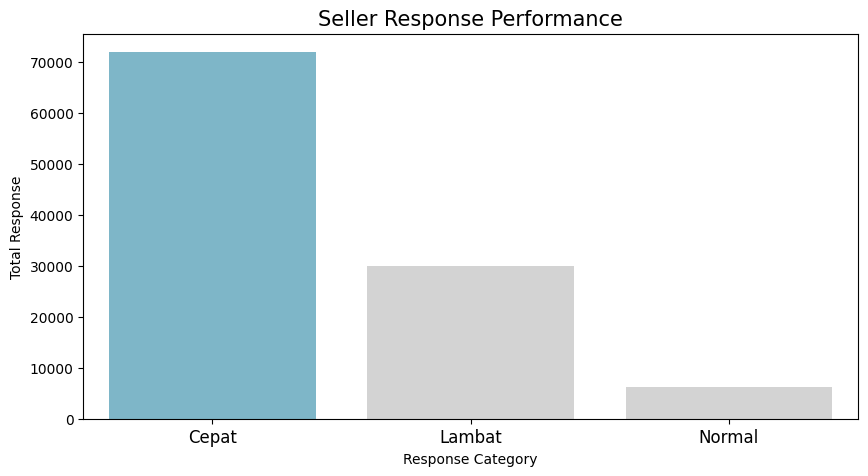

In [52]:
seller_response.rename(columns={
    "response_time_hour": "response_count"
}, inplace=True)

colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

plt.figure(figsize=(10, 5))

sns.barplot(
    y="response_count", 
    x="response_category",
    data=seller_response.sort_values(by="response_count", ascending=False),
    palette=colors
)

plt.title("Seller Response Performance", loc="center", fontsize=15)
plt.ylabel("Total Response")
plt.xlabel("Response Category")
plt.tick_params(axis='x', labelsize=12)
plt.show()

- Apa produk dengan nilai review tertinggi dan terendah?

Melakukan groupby untuk menemukan produk dengan rating tertinggi dan terendah berdaarkan rata rata review score

In [53]:
review_rate = all_df.groupby("product_category_name_english").agg({
    "review_score": "mean"
}).sort_values(by="review_score", ascending=False)
review_rate

,review_score
product_category_name_english,
fashion_childrens_clothes,5.000000
cds_dvds_musicals,4.642857
books_general_interest,4.510358
books_imported,4.508772
costruction_tools_tools,4.444444
...,...
fixed_telephony,3.757937
home_comfort_2,3.629630
office_furniture,3.516888


Melakukan visualisasi dengan barchart pada produk terbaik dan produk terburuk

C:\Users\nicol\AppData\Local\Temp\ipykernel_9148\1458528679.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="review_score", y="product_category_name_english", data=review_rate.head(5), palette=colors, ax=ax[0])


C:\Users\nicol\AppData\Local\Temp\ipykernel_9148\1458528679.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="review_score", y="product_category_name_english", data=review_rate.sort_values(by="review_score", ascending=True).head(5), palette=colors, ax=ax[1])


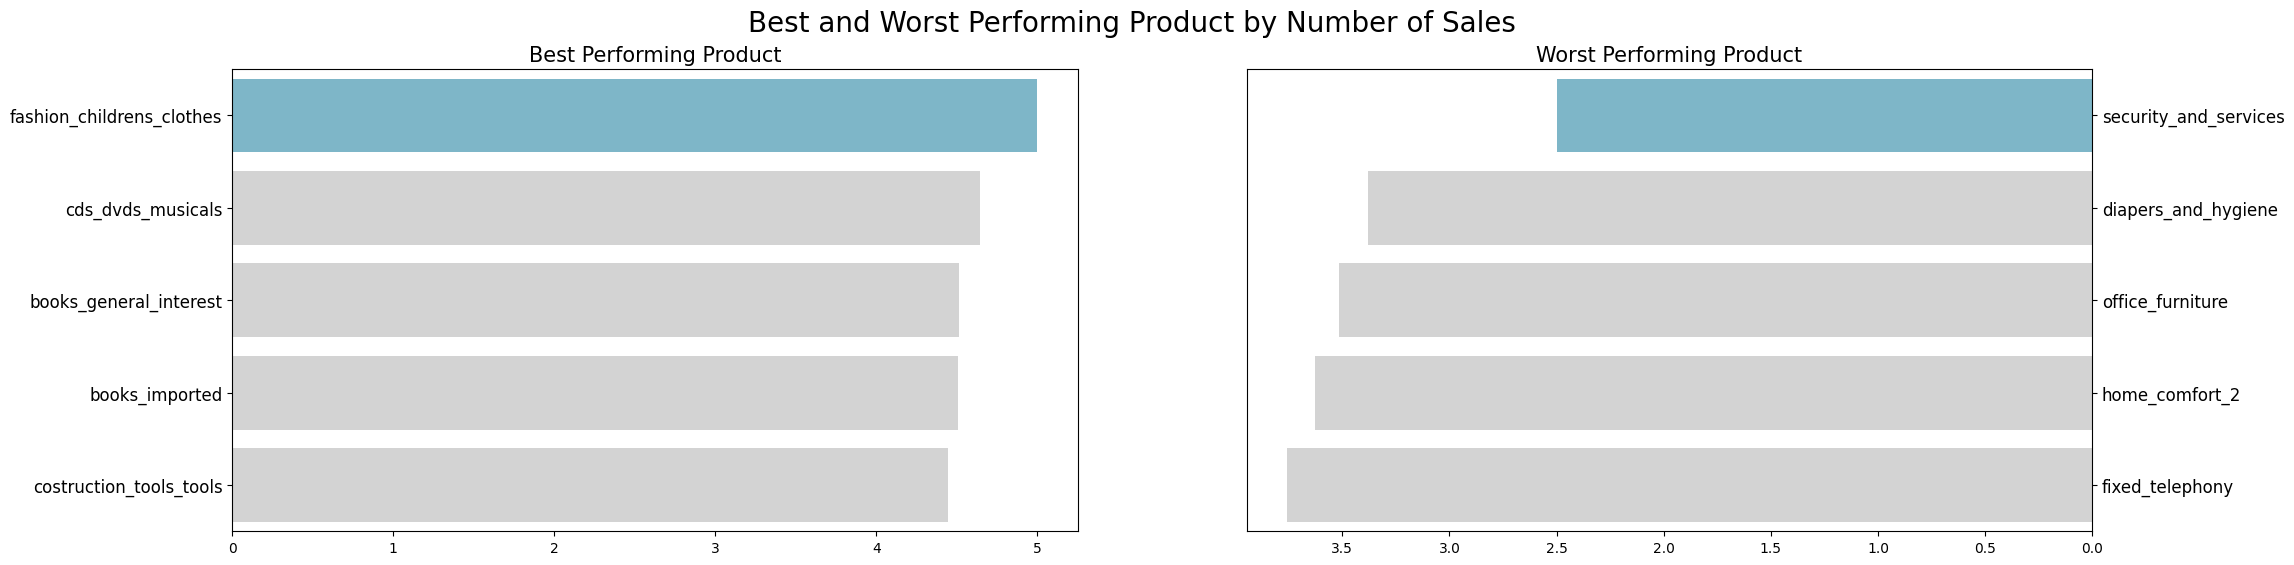

In [54]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 6))

colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

sns.barplot(x="review_score", y="product_category_name_english", data=review_rate.head(5), palette=colors, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("Best Performing Product", loc="center", fontsize=15)
ax[0].tick_params(axis ='y', labelsize=12)

sns.barplot(x="review_score", y="product_category_name_english", data=review_rate.sort_values(by="review_score", ascending=True).head(5), palette=colors, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("Worst Performing Product", loc="center", fontsize=15)
ax[1].tick_params(axis='y', labelsize=12)

plt.suptitle("Best and Worst Performing Product by Number of Sales", fontsize=20)
plt.show()

- Bagaimana persebaran tempat tinggal pembeli dan penjual?

-- Geoanalisis dengan pemetaan data geografis untuk membuat peta yang memvisualisasikan distribusi lokasi seller dan customer

Mengganti nama kolom sesuai role seller atau customer dan melakukan penggabungan menjadi user_location_df

In [55]:
seller_location_df = all_df[['seller_id', 'role_seller', 'seller_city', 'geolocation_lat_seller', 'geolocation_lng_seller']].rename(columns={'seller_id': 'user_id', 'role_seller': 'role', 'geolocation_lat_seller': 'Latitude', 'geolocation_lng_seller': 'Longitude'}).drop_duplicates()
customer_location_df = all_df[['customer_id', 'role_customer', 'customer_city','geolocation_lat_customer', 'geolocation_lng_customer']].rename(columns={'customer_id': 'user_id', 'role_customer': 'role', 'geolocation_lat_customer': 'Latitude', 'geolocation_lng_customer': 'Longitude'}).drop_duplicates()
user_location_df = pd.concat([seller_location_df, customer_location_df], ignore_index=True)
user_location_df

,user_id,role,seller_city,Latitude,Longitude,customer_city
0,48436dade18ac8b2bce089ec2a041202,seller,volta redonda,-22.497188,-44.127324,NaN
1,0db783cfcd3b73998abc6e10e59a102f,seller,santos,-23.933825,-46.329330,NaN
2,46dc3b2cc0980fb8ec44634e21d2718e,seller,rio de janeiro,-22.935434,-43.187461,NaN
3,dd7ddc04e1b6c2c614352b383efe2d36,seller,sao paulo,-23.565754,-46.519097,NaN
4,070d165398b553f3b4b851c216b8a358,seller,sao paulo,-23.588533,-46.511321,NaN
...,...,...,...,...,...,...
96898,1d3e643209846ffadac771cc5dc1ed4b,customer,NaN,-19.020414,-57.656290,corumba
96899,fef79774a4f4ef014078bcb0b42d0cc5,customer,NaN,-12.982755,-38.457272,salvador
96900,81ae83ce1a10af9f93fa3512bd9713b1,customer,NaN,-22.999730,-43.401029,rio de janeiro
96901,94203a446c1b46b5ac95b0aaf7221804,customer,NaN,-22.545862,-47.391286,limeira


Melakukan groupby untuk menemukan lokasi seller tertinggi dan lokasi customer tertinggi

In [56]:
a = user_location_df.groupby(by="seller_city").agg({
    "user_id": "count"
}).sort_values(by="user_id", ascending=False)
b = user_location_df.groupby(by="customer_city").agg({
    "user_id": "count"
}).sort_values(by="user_id", ascending=False)

print(a)
print(b)

                user_id
seller_city            
sao paulo           646
curitiba            119
rio de janeiro       90
belo horizonte       62
ribeirao preto       49
...                 ...
itirapina             1
itau de minas         1
itapui                1
itaporanga            1
xaxim                 1

[587 rows x 1 columns]
                     user_id
customer_city               
sao paulo              14679
rio de janeiro          6406
belo horizonte          2626
brasilia                1869
curitiba                1462
...                      ...
iaras                      1
ibarama                    1
ibema                      1
rio grande do piaui        1
zortea                     1

[4023 rows x 1 columns]


Melakukan visualisasi persebaran seller dan customer pada map

C:\Users\nicol\AppData\Local\Temp\ipykernel_9148\3797369234.py:8: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


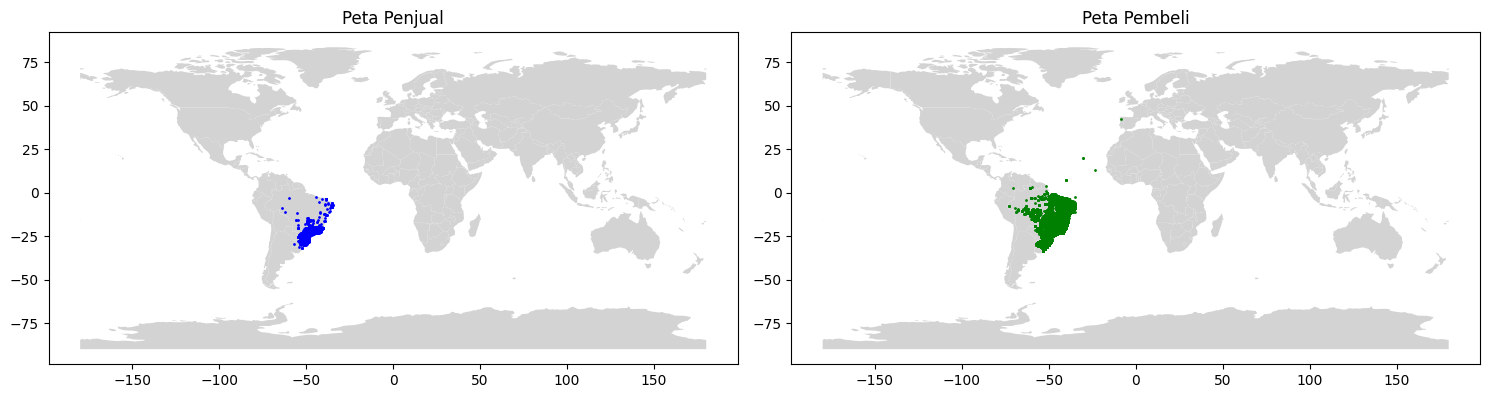

In [57]:
geometry = gpd.points_from_xy(user_location_df['Longitude'], user_location_df['Latitude'])
gdf = gpd.GeoDataFrame(user_location_df, geometry=geometry)

gdf_seller = gdf[gdf['role'] == 'seller']
gdf_customer = gdf[gdf['role'] == 'customer']

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

world.plot(ax=ax[0], color='lightgrey')
gdf_seller.plot(ax=ax[0], color='blue', marker='o', markersize=1)
ax[0].set_title('Peta Penjual')

world.plot(ax=ax[1], color='lightgrey')
gdf_customer.plot(ax=ax[1], color='green', marker='o', markersize=1)
ax[1].set_title('Peta Pembeli')

plt.tight_layout()
plt.show()

Melakukan visualisasi barchart pada lokasi seller tertinggi dan lokasi customer tertinggi

C:\Users\nicol\AppData\Local\Temp\ipykernel_9148\1745448339.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="user_id", y="seller_city", data=a.head(5), palette=colors, ax=ax[0])
C:\Users\nicol\AppData\Local\Temp\ipykernel_9148\1745448339.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="user_id", y="customer_city", data=b.sort_values(by="user_id", ascending=False).head(5), palette=colors, ax=ax[1])


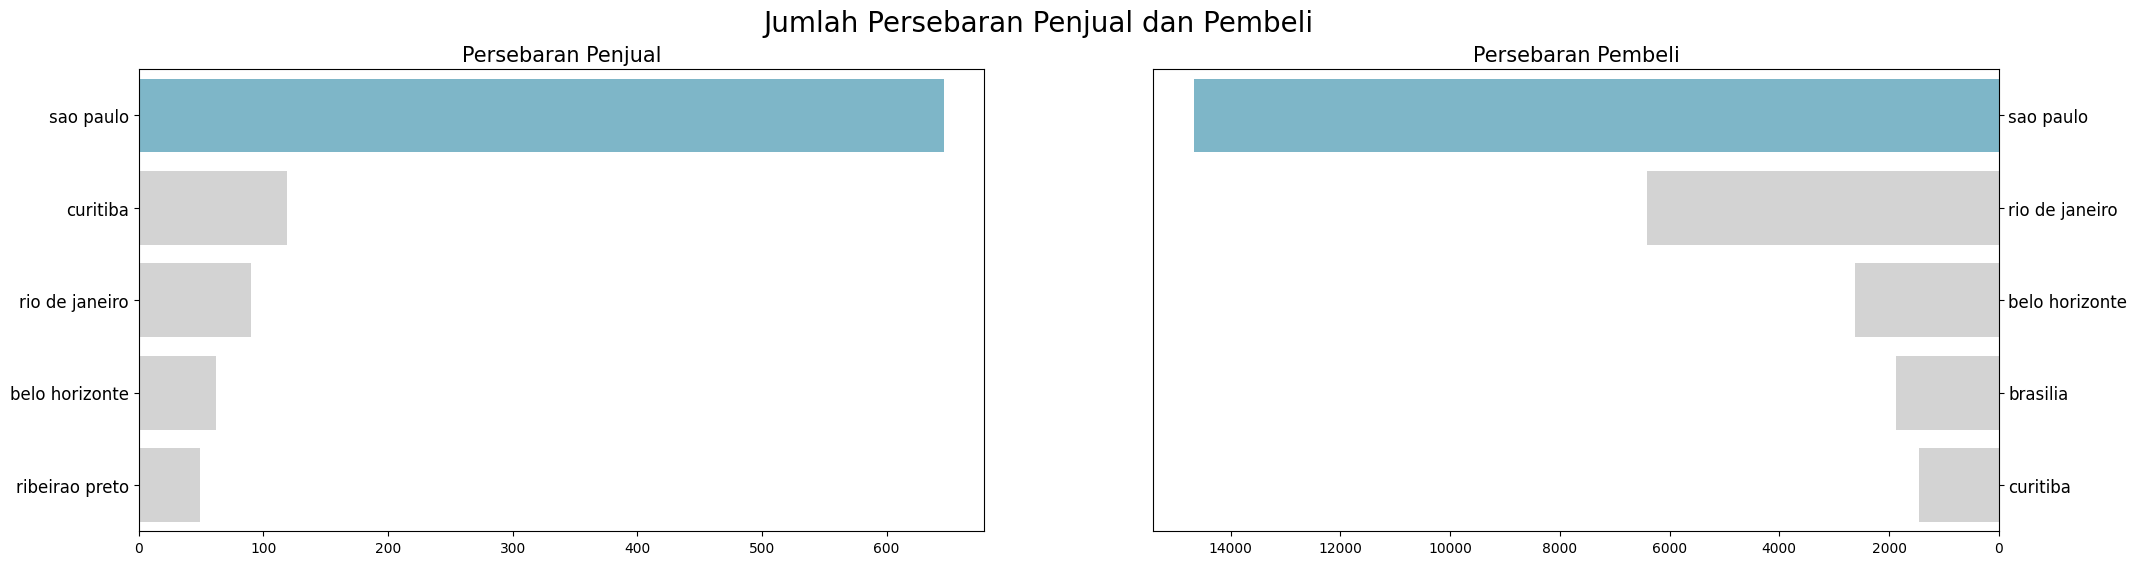

In [58]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 6))

colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

sns.barplot(x="user_id", y="seller_city", data=a.head(5), palette=colors, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("Persebaran Penjual", loc="center", fontsize=15)
ax[0].tick_params(axis ='y', labelsize=12)

sns.barplot(x="user_id", y="customer_city", data=b.sort_values(by="user_id", ascending=False).head(5), palette=colors, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("Persebaran Pembeli", loc="center", fontsize=15)
ax[1].tick_params(axis='y', labelsize=12)

plt.suptitle("Jumlah Persebaran Penjual dan Pembeli", fontsize=20)
plt.show()

## Conclusion

- Bagaimana performa respon penjual berdasarkan waktu pesanan dan waktu diterima?

Berdasarkan bentuk visualisasi diatas dapat disimpulkan bahwa performa dari respon penjual sangat banyak yang merespon dengan cepat, tapi cukup banyak juga yang masih lambat dalam merespon, dan diikuti respon yang normal yang sedikit jika dibandingkan respon yang cepat dan lambat

- Apa produk dengan nilai review tertinggi dan terendah?

Produk dengan nilai review tertinggi yaitu fashion_childrens_clothes dengan review_score 5.00 dan produk dengan nilai review terburuk security_and_services dengan review score 2.50

- Bagaimana persebaran tempat tinggal pembeli dan penjual?

-- Geoanalisis dengan pemetaan data geografis untuk membuat peta yang memvisualisasikan distribusi lokasi seller dan customer

Lokasi tempat tinggal penjual tertinggi berada di sao paulo diikuti curitiba, rio de janeiro, belo horizonte, dan ribeirao preto. Sedangkan lokasi tempat tinggal pembeli tertinggi berada di sao paulo diikuti rio de janeiro, belo horizonte, brasilia, dan curitiba 

In [59]:
all_df.to_csv("dashboard/all_data.csv", index=False)